<hr size=5 color='#002883'>

<p align="center"> <font size=7 color='#002883'> Elaboração de cartas sinóticas utilizando o produto de Reanalysis ERA5

<hr size=5 color='#002883'>

<p align="left"> <font size=5 color='#002883'> Professores:  

* Prof. Dr. Pedro Leite da Silva Dias
* Prof. Dr. Ricardo Hallak


<p align="left"> <font size=5 color='#002883'> Estudante:

* Ronald Guiuseppi Ramírez Nina [PhD. Candidate in Atmospheric Sciences]
* email: ronald.ramirez.nina@alumni.usp.br / ronald.ramirez.nina@usp.br

<hr size=5 color='#002883'>

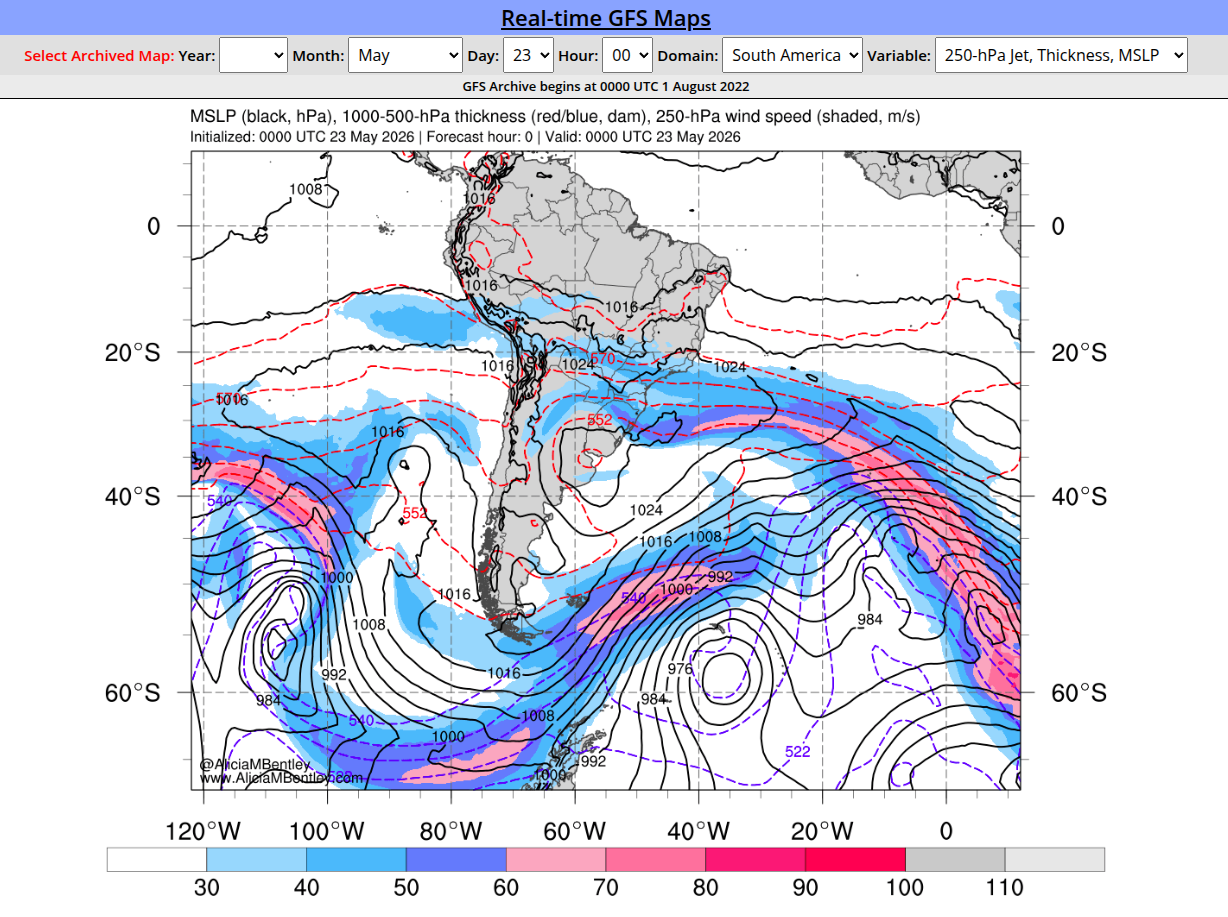

**Baseado no site de Alicia M. Bentley**

Link do site: https://www.atmos.albany.edu/student/abentley/realtime.html

<hr size=5 color='#002883'>

# <font size=6 color='#002883'> **1. preparação do Colab** <font>

<font size=4 color='#002883'> Executar as duas células de abaixo: <font>

In [1]:
# @title #### <font color='#002883'> Instalar livrarias <font>
%%capture
!pip install xarray netCDF4 scipy scikit-learn dask pydap bottleneck h5netcdf
!pip install store zarr
!pip install uv
!pip install cartopy
!pip install cmocean
!pip install metpy

<font size=4 color='#002883'> **2. Importar livrarias e montar o drive** <font>

In [2]:
# @title #### <font color='#002883'> Importar livrarias <font>
%%capture
# Livrarias para ler e processar dados
import xarray as xr
import pandas as pd
import numpy as np
from scipy.signal import butter, filtfilt
import metpy.calc as mpcalc
from metpy.units import units

# Livrarias para gerar gráficos
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter
import matplotlib as mpl
import matplotlib.colors as colors
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import cmocean as cmo
import os

# Importar o drive
from google.colab import drive
drive.mount('/content/drive')

<hr size=5 color='#002883'>

# <font size=6 color='#002883'> **3. Acessar aos dados do [Earth Data catalogue](https://earthdatahub.destine.eu/catalogue)** <font>

- <font size=4 color='#002883'>Earth Data catalogue link: [Earth Data catalogue](https://earthdatahub.destine.eu/catalogue) <font>

<font size=4 color= '#002883'>**Acessar ao Site e criar uma conta, no qual vocês poderão criar seus própios tokens, necessários para fazer usso dos diferentes conjuntos de dados disponíveis <font>**.

In [3]:
# @title #### <font color='#002883'> Acessar através do access token <font>
%%capture
token = "edh_pat_d2c59b08304ab1489023f5c02db65f5bf6fc852132871ec4f00bd467d161b66655d85b2a7415725b7c2b6ca8bfed27c0"
edh_pat = os.getenv("EDH_PAT", token)

assert edh_pat.startswith("edh_pat_"), (
    f"Your personal access token is a long string starting with 'edh_pat_', not {edh_pat!r}"
)

<font size=4 color='#002883'> **4. Ler o dataset horário do ERA5 Pressure Levels
utilizando o token** <font>

In [4]:
# @title #### <font color='#002883'> Ler dataset utiizando o token  <font>
#%%capture

# Link de acesso aos dados horários por níveis de pressão de todo o histórico do ERA5
link_era5_pressure_levels = "data.earthdatahub.destine.eu/era5/reanalysis-era5-pressure-levels-v0.zarr"
# Ler dataset
era5_pressure_levels_hourly = xr.open_dataset(
    f"https://edh:{edh_pat}@{link_era5_pressure_levels}",
    chunks={},
    engine="zarr",
)

# Display dos dados
era5_pressure_levels_hourly

<xarray.Dataset> Size: 955TB
Dimensions:        (valid_time: 756768, isobaricInhPa: 19, latitude: 721,
                    longitude: 1440)
Coordinates:
  * valid_time     (valid_time) datetime64[ns] 6MB 1940-01-01 ... 2026-04-30T...
  * isobaricInhPa  (isobaricInhPa) int32 76B 1000 925 850 700 600 ... 20 10 5 1
  * latitude       (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude      (longitude) float64 12kB 0.0 0.25 0.5 ... 359.2 359.5 359.8
    number         int64 8B ...
Data variables: (12/16)
    cc             (valid_time, isobaricInhPa, latitude, longitude) float32 60TB dask.array<chunksize=(120, 1, 256, 256), meta=np.ndarray>
    ciwc           (valid_time, isobaricInhPa, latitude, longitude) float32 60TB dask.array<chunksize=(120, 1, 256, 256), meta=np.ndarray>
    clwc           (valid_time, isobaricInhPa, latitude, longitude) float32 60TB dask.array<chunksize=(120, 1, 256, 256), meta=np.ndarray>
    crwc           (valid_time, isobaricInhPa, latitude, longitude) float32 60TB dask.array<chunksize=(120, 1, 256, 256), meta=np.ndarray>
    cswc           (valid_time, isobaricInhPa, latitude, longitude) float32 60TB dask.array<chunksize=(120, 1, 256, 256), meta=np.ndarray>
    d              (valid_time, isobaricInhPa, latitude, longitude) float32 60TB dask.array<chunksize=(120, 1, 256, 256), meta=np.ndarray>
    ...             ...
    t              (valid_time, isobaricInhPa, latitude, longitude) float32 60TB dask.array<chunksize=(120, 1, 256, 256), meta=np.ndarray>
    u              (valid_time, isobaricInhPa, latitude, longitude) float32 60TB dask.array<chunksize=(120, 1, 256, 256), meta=np.ndarray>
    v              (valid_time, isobaricInhPa, latitude, longitude) float32 60TB dask.array<chunksize=(120, 1, 256, 256), meta=np.ndarray>
    vo             (valid_time, isobaricInhPa, latitude, longitude) float32 60TB dask.array<chunksize=(120, 1, 256, 256), meta=np.ndarray>
    w              (valid_time, isobaricInhPa, latitude, longitude) float32 60TB dask.array<chunksize=(120, 1, 256, 256), meta=np.ndarray>
    z              (valid_time, isobaricInhPa, latitude, longitude) float32 60TB dask.array<chunksize=(120, 1, 256, 256), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2024-11-15T16:05 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

<font size=4 color='#002883'> **5. Selecionar a área de estudo, em função do ciclone/furacão de interesse. Neste caso, como exemplo foi eleito o furacão Catarina. Converter as longitudes do formato de 0° a 360° para o formato de -180° a +180° (Porém, se for necessário pode manter o formato de 0° - 360°). Selecionar o período de estudo. Finalmente, selecionar os níveis de pressão** <font>

In [5]:
# @title #### <font color='#002883'> Selecionar a área, tranfomar o formato das longitudes e escolher o período  <font>
#%%capture

# Selecionar área e período
# Data inicial
start_time = '2026-04-25'
# Data final
end_time = '2026-04-30'

# Selecionar as latitudes e longitudes minima e máximo
# Domínio parecido com a figura
lon_min = -120
lon_max = 15
lat_min = -72
lat_max = 12

# Selecionar período
ds_pressure_levels = era5_pressure_levels_hourly.sel(latitude=slice(lat_max, lat_min), valid_time=slice(start_time,end_time))
# Dar atributos à coordenada de tempo
ds_pressure_levels["valid_time"].attrs.update({
    "long_name": "time",
    "standard_name": "time",
})

# Selecionar os níveis de pressão, e.g., 1000 até 100 hPa
ds_pressure_levels = ds_pressure_levels.sel(isobaricInhPa=slice(1000,100))
# Renomear a coordenada vertical
ds_pressure_levels = ds_pressure_levels.rename({"isobaricInhPa":"pressure_level"})
# Dar atributos à coordenada vertical, e.g., a unidade hPa
ds_pressure_levels["pressure_level"].attrs.update({
    "long_name": "pressure",
    "units": "hPa",
    "positive": "down",
    "stored_direction": "decreasing",
    "standard_name": "air_pressure",
})

# Transformar o formato das longitudes
ds_pressure_levels['longitude'] = (ds_pressure_levels.coords['longitude'] + 180) % 360 - 180
ds_pressure_levels = ds_pressure_levels.sortby(ds_pressure_levels.longitude)
# Selecionar área e período
ds_pressure_levels = ds_pressure_levels.sel(longitude=slice(lon_min, lon_max))

# Selecionar os pasos de tempo, e.g., time_step = 3 horas ou 6 horas
time_step = 6 # horas: Pode trocar para 3
hours_keep = list(range(0,24,time_step))
ds_pressure_levels = ds_pressure_levels.sel(valid_time = ds_pressure_levels.valid_time.dt.hour.isin(hours_keep))
ds_pressure_levels

<xarray.Dataset> Size: 3GB
Dimensions:         (valid_time: 24, pressure_level: 12, latitude: 337,
                     longitude: 541)
Coordinates:
  * valid_time      (valid_time) datetime64[ns] 192B 2026-04-25 ... 2026-04-3...
  * pressure_level  (pressure_level) int32 48B 1000 925 850 700 ... 200 150 100
  * latitude        (latitude) float64 3kB 12.0 11.75 11.5 ... -71.75 -72.0
  * longitude       (longitude) float64 4kB -120.0 -119.8 -119.5 ... 14.75 15.0
    number          int64 8B ...
Data variables: (12/16)
    cc              (valid_time, pressure_level, latitude, longitude) float32 210MB dask.array<chunksize=(24, 1, 200, 240), meta=np.ndarray>
    ciwc            (valid_time, pressure_level, latitude, longitude) float32 210MB dask.array<chunksize=(24, 1, 200, 240), meta=np.ndarray>
    clwc            (valid_time, pressure_level, latitude, longitude) float32 210MB dask.array<chunksize=(24, 1, 200, 240), meta=np.ndarray>
    crwc            (valid_time, pressure_level, latitude, longitude) float32 210MB dask.array<chunksize=(24, 1, 200, 240), meta=np.ndarray>
    cswc            (valid_time, pressure_level, latitude, longitude) float32 210MB dask.array<chunksize=(24, 1, 200, 240), meta=np.ndarray>
    d               (valid_time, pressure_level, latitude, longitude) float32 210MB dask.array<chunksize=(24, 1, 200, 240), meta=np.ndarray>
    ...              ...
    t               (valid_time, pressure_level, latitude, longitude) float32 210MB dask.array<chunksize=(24, 1, 200, 240), meta=np.ndarray>
    u               (valid_time, pressure_level, latitude, longitude) float32 210MB dask.array<chunksize=(24, 1, 200, 240), meta=np.ndarray>
    v               (valid_time, pressure_level, latitude, longitude) float32 210MB dask.array<chunksize=(24, 1, 200, 240), meta=np.ndarray>
    vo              (valid_time, pressure_level, latitude, longitude) float32 210MB dask.array<chunksize=(24, 1, 200, 240), meta=np.ndarray>
    w               (valid_time, pressure_level, latitude, longitude) float32 210MB dask.array<chunksize=(24, 1, 200, 240), meta=np.ndarray>
    z               (valid_time, pressure_level, latitude, longitude) float32 210MB dask.array<chunksize=(24, 1, 200, 240), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2024-11-15T16:05 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

<font size=4 color='#002883'> **6. Ler o dataset horário do ERA5 Single Levels
utilizando o token** <font>

In [6]:
# @title #### <font color='#002883'> Ler dataset utiizando o token  <font>
#%%capture

# Link de acesso aos dados horários por níveis de pressão de todo o histórico do ERA5
link_era5_single_levels = "data.earthdatahub.destine.eu/era5/reanalysis-era5-single-levels-v0.zarr"
# Ler dataset
era5_single_levels_hourly = xr.open_dataset(
    f"https://edh:{edh_pat}@{link_era5_single_levels}",
    chunks={},
    engine="zarr",
)

# Display dos dados
era5_single_levels_hourly

<xarray.Dataset> Size: 405TB
Dimensions:     (valid_time: 756768, latitude: 721, longitude: 1440)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 6MB 1940-01-01 ... 2026-04-30T23:...
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    number      int64 8B ...
    surface     float64 8B ...
Data variables: (12/129)
    alnid       (valid_time, latitude, longitude) float32 3TB dask.array<chunksize=(4320, 64, 64), meta=np.ndarray>
    alnip       (valid_time, latitude, longitude) float32 3TB dask.array<chunksize=(4320, 64, 64), meta=np.ndarray>
    aluvd       (valid_time, latitude, longitude) float32 3TB dask.array<chunksize=(4320, 64, 64), meta=np.ndarray>
    aluvp       (valid_time, latitude, longitude) float32 3TB dask.array<chunksize=(4320, 64, 64), meta=np.ndarray>
    anor        (valid_time, latitude, longitude) float32 3TB dask.array<chunksize=(4320, 64, 64), meta=np.ndarray>
    asn         (valid_time, latitude, longitude) float32 3TB dask.array<chunksize=(4320, 64, 64), meta=np.ndarray>
    ...          ...
    viiwn       (valid_time, latitude, longitude) float32 3TB dask.array<chunksize=(4320, 64, 64), meta=np.ndarray>
    vilwd       (valid_time, latitude, longitude) float32 3TB dask.array<chunksize=(4320, 64, 64), meta=np.ndarray>
    vilwe       (valid_time, latitude, longitude) float32 3TB dask.array<chunksize=(4320, 64, 64), meta=np.ndarray>
    vilwn       (valid_time, latitude, longitude) float32 3TB dask.array<chunksize=(4320, 64, 64), meta=np.ndarray>
    z           (valid_time, latitude, longitude) float32 3TB dask.array<chunksize=(4320, 64, 64), meta=np.ndarray>
    zust        (valid_time, latitude, longitude) float32 3TB dask.array<chunksize=(4320, 64, 64), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2025-12-04T16:25 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

<font size=4 color='#002883'> **7. Selecionar a área de estudo, em função do ciclone/furacão de interesse. Neste caso, como exemplo foi eleito o furacão Catarina. Converter as longitudes do formato de 0° a 360° para o formato de -180° a +180° (Porém, se for necessário pode manter o formato de 0° - 360°). Selecionar o período de estudo.** <font>

In [34]:
# @title #### <font color='#002883'> Selecionar a área de estudo  <font>
#%%capture

# Selecionar período
ds_single_levels = era5_single_levels_hourly.sel(latitude=slice(lat_max, lat_min), valid_time=slice(start_time,end_time))
# Dar atributos à coordenada de tempo
ds_single_levels["valid_time"].attrs.update({
    "long_name": "time",
    "standard_name": "time",
})

# Transformar o formato das longitudes
ds_single_levels['longitude'] = (ds_single_levels.coords['longitude'] + 180) % 360 - 180
ds_single_levels = ds_single_levels.sortby(ds_single_levels.longitude)
# Selecionar área e período
ds_single_levels = ds_single_levels.sel(longitude=slice(lon_min, lon_max))

# Selecionar os pasos de tempo, e.g., time_step = 3 horas ou 6 horas
time_step = 6 # horas: Pode trocar para 3
hours_keep = list(range(0,24,time_step))
ds_single_levels = ds_single_levels.sel(valid_time = ds_single_levels.valid_time.dt.hour.isin(hours_keep))
ds_single_levels

<xarray.Dataset> Size: 2GB
Dimensions:     (valid_time: 24, latitude: 337, longitude: 541)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 192B 2026-04-25 ... 2026-04-30T18...
  * latitude    (latitude) float64 3kB 12.0 11.75 11.5 ... -71.5 -71.75 -72.0
  * longitude   (longitude) float64 4kB -120.0 -119.8 -119.5 ... 14.5 14.75 15.0
    number      int64 8B ...
    surface     float64 8B ...
Data variables: (12/129)
    alnid       (valid_time, latitude, longitude) float32 18MB dask.array<chunksize=(24, 8, 8), meta=np.ndarray>
    alnip       (valid_time, latitude, longitude) float32 18MB dask.array<chunksize=(24, 8, 8), meta=np.ndarray>
    aluvd       (valid_time, latitude, longitude) float32 18MB dask.array<chunksize=(24, 8, 8), meta=np.ndarray>
    aluvp       (valid_time, latitude, longitude) float32 18MB dask.array<chunksize=(24, 8, 8), meta=np.ndarray>
    anor        (valid_time, latitude, longitude) float32 18MB dask.array<chunksize=(24, 8, 8), meta=np.ndarray>
    asn         (valid_time, latitude, longitude) float32 18MB dask.array<chunksize=(24, 8, 8), meta=np.ndarray>
    ...          ...
    viiwn       (valid_time, latitude, longitude) float32 18MB dask.array<chunksize=(24, 8, 8), meta=np.ndarray>
    vilwd       (valid_time, latitude, longitude) float32 18MB dask.array<chunksize=(24, 8, 8), meta=np.ndarray>
    vilwe       (valid_time, latitude, longitude) float32 18MB dask.array<chunksize=(24, 8, 8), meta=np.ndarray>
    vilwn       (valid_time, latitude, longitude) float32 18MB dask.array<chunksize=(24, 8, 8), meta=np.ndarray>
    z           (valid_time, latitude, longitude) float32 18MB dask.array<chunksize=(24, 8, 8), meta=np.ndarray>
    zust        (valid_time, latitude, longitude) float32 18MB dask.array<chunksize=(24, 8, 8), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2025-12-04T16:25 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

<font size=4 color='#002883'> **7.1. No caso da precipitação, precisa ser selecionado datas anteriores. Caso o time_step = 6 horas, a data para a preceipitação precisa ser desde as 17 horas do dia anterior ao selecionado no anterior passo. Neste exemplo seria desde o dia 2026-04-24 as 19 horas. Isso porque o acumulado de precipitação do dia 2026-04-25 as 00 UTC corresponde à soma do dia 2026-04-24 desde 19 horas até as 00 horas (do dia seguinte).** <font>

<font size=4 color='#002883'> **Exemplo para step_hours=6:**


* <font size=4 color='#002883'> **2026-04-26 00 UTC = soma de 19, 20, 21, 22, 23 (2026-04-24), 00 UTC (2026-04-25)**
* **2026-04-26 06 UTC = soma de 01, 02, 03, 04, 05, 06 UTC (2026-04-26)**
* **2026-04-26 12 UTC = soma de 07, 08, 09, 10, 11, 12 UTC (2026-04-26)**
* **2026-04-26 18 UTC = soma de 13, 14, 15, 16, 17, 18 UTC (2026-04-26)**
        

In [27]:
# @title #### <font color='#002883'> Selecionar o período para a precipitação <font>
#%%capture

# Selecionar período para a precipitação
# Data inicial
start_time_prec = '2026-04-24T19:00:00.000000000'
# Data final
end_time_prec = '2026-04-30'

# Selecionar período
precipitation_hourly = era5_single_levels_hourly[['tp']].sel(latitude=slice(lat_max, lat_min), valid_time=slice(start_time_prec, end_time_prec))
# Dar atributos à coordenada de tempo
precipitation_hourly["valid_time"].attrs.update({
    "long_name": "time",
    "standard_name": "time",
})

# Transformar o formato das longitudes
precipitation_hourly['longitude'] = (precipitation_hourly.coords['longitude'] + 180) % 360 - 180
precipitation_hourly = precipitation_hourly.sortby(precipitation_hourly.longitude)
# Selecionar área e período
precipitation_hourly = precipitation_hourly.sel(longitude=slice(lon_min, lon_max))
precipitation_hourly

<xarray.Dataset> Size: 109MB
Dimensions:     (valid_time: 149, latitude: 337, longitude: 541)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 1kB 2026-04-24T19:00:00 ... 2026-...
  * latitude    (latitude) float64 3kB 12.0 11.75 11.5 ... -71.5 -71.75 -72.0
  * longitude   (longitude) float64 4kB -120.0 -119.8 -119.5 ... 14.5 14.75 15.0
    number      int64 8B ...
    surface     float64 8B ...
Data variables:
    tp          (valid_time, latitude, longitude) float32 109MB dask.array<chunksize=(149, 8, 8), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2025-12-04T16:25 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

<font size=4 color='#002883'> **7.2. Função para calcular o acumulado de precipitação em função do time_step (neste exemplo foi de 6 horas)** <font>

In [28]:
# @title #### <font color='#002883'> Função para criar os acumulados de precipitação <font>
#%%capture

# ==========================================================
# Função para acumular precipitação horária em janelas fixas
# Exemplo: 6h -> 01-06, 07-12, 13-18, 19-00
# ==========================================================

def accumulate_precipitation(
    ds,
    step_hours=6,
    time_dim="valid_time",
    drop_incomplete=True,
):
    """
    Calcula precipitação acumulada em janelas de step_hours,
    salvando cada acumulado no último horário da janela.

    Exemplo para step_hours=6:
        06 UTC = soma de 01, 02, 03, 04, 05, 06 UTC
        12 UTC = soma de 07, 08, 09, 10, 11, 12 UTC
        18 UTC = soma de 13, 14, 15, 16, 17, 18 UTC
        00 UTC = soma de 19, 20, 21, 22, 23, 00 UTC
    """

    # Garante que o tempo esteja ordenado
    ds = ds.sortby(time_dim)

    freq = f"{step_hours}h"

    # Soma em janelas fechadas à direita:
    # (00, 06] -> inclui 01,02,03,04,05,06
    # (06, 12] -> inclui 07,08,09,10,11,12
    # (18, 00] -> inclui 19,20,21,22,23,00 do dia seguinte
    ds_acc = ds.resample(
        {time_dim: freq},
        closed="right",
        label="right",
        origin="start_day",
    ).sum(
        dim=time_dim,
        skipna=True,
        min_count=step_hours,
        keep_attrs=True,
    )

    # Remove janelas incompletas.
    # Isso é importante porque, se o dataset começa em 00 UTC,
    # o primeiro bin rotulado como 00 teria apenas uma hora.
    if drop_incomplete:
        count_time = xr.DataArray(
            np.ones(ds.sizes[time_dim], dtype=np.int16),
            coords={time_dim: ds[time_dim]},
            dims=time_dim,
            name="n_hours",
        )

        count_acc = count_time.resample(
            {time_dim: freq},
            closed="right",
            label="right",
            origin="start_day",
        ).sum()

        ds_acc = ds_acc.where(count_acc == step_hours, drop=True)

    # Atualiza atributos
    if isinstance(ds_acc, xr.Dataset):
        for var in ds_acc.data_vars:
            ds_acc[var].attrs["accumulation_period"] = f"{step_hours} hours"
            ds_acc[var].attrs["time_label"] = "end of accumulation window"
            ds_acc[var].attrs["window_definition"] = f"(t - {step_hours}h, t]"
    else:
        ds_acc.attrs["accumulation_period"] = f"{step_hours} hours"
        ds_acc.attrs["time_label"] = "end of accumulation window"
        ds_acc.attrs["window_definition"] = f"(t - {step_hours}h, t]"

    return ds_acc

<font size=4 color='#002883'> **7.3. Aplicação da função e geração do novo dataset de precipitação acumumalada em função do time_step (neste exemplo foi de 6 horas)** <font>

In [29]:
# @title #### <font color='#002883'> Aplicação da função de precipitação acumulada <font>
#%%capture

# Aplicação da função de precipitação acumulada
precipitation_6h = accumulate_precipitation(
    precipitation_hourly,
    step_hours=6,
    time_dim="valid_time",
)

precipitation_6h

<xarray.Dataset> Size: 18MB
Dimensions:     (valid_time: 24, latitude: 337, longitude: 541)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 192B 2026-04-25 ... 2026-04-30T18...
  * latitude    (latitude) float64 3kB 12.0 11.75 11.5 ... -71.5 -71.75 -72.0
  * longitude   (longitude) float64 4kB -120.0 -119.8 -119.5 ... 14.5 14.75 15.0
    number      int64 8B ...
    surface     float64 8B ...
Data variables:
    tp          (valid_time, latitude, longitude) float32 18MB dask.array<chunksize=(1, 8, 8), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2025-12-04T16:25 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

<font size=4 color='#002883'> **8. Funções de identificação de coordenadas espaciais, temporal, de reconhecimento de variáveis. Função de savizado Gaussiano para reduzir o ruído** <font>

In [30]:
# @title #### <font color='#002883'> Criação de funções complementárias <font>
#%%capture

from scipy.ndimage import gaussian_filter

# ==========================================================
# FUNÇÕES AUXILIARES
# ==========================================================

def find_coord(ds, candidates):
    """
    Encontra automaticamente o nome de uma coordenada no Dataset.
    """
    for name in candidates:
        if name in ds.coords or name in ds.dims:
            return name
    raise ValueError(f"Nenhuma coordenada encontrada entre: {candidates}")


def find_var(ds, candidates):
    """
    Encontra automaticamente o nome de uma variável no Dataset.
    """
    for name in candidates:
        if name in ds.data_vars:
            return name
    raise ValueError(f"Nenhuma variável encontrada entre: {candidates}")

def select_time(da, time_index=0):
    """
    Seleciona o tempo se a variável tiver dimensão temporal.
    """
    for tname in ["valid_time", "time", "forecast_time"]:
        if tname in da.dims:
            return da.isel({tname: time_index})
    return da


def select_level(da, level_name, level_value):
    """
    Seleciona nível de pressão.
    """
    return da.sel({level_name: level_value}, method="nearest")

def smooth_gaussian_2d(da, lat_name="latitude", lon_name="longitude", sigma=1.0):
    """
    Aplica filtro gaussiano 2D em um xarray.DataArray.

    sigma está em unidades de grid points.
    Exemplo:
        sigma=1.0  -> suavização leve
        sigma=1.5  -> suavização moderada
        sigma=2.0  -> suavização mais forte
    """

    # Garantir ordem das dimensões
    da_t = da.transpose(lat_name, lon_name)

    data_smooth = gaussian_filter(
        da_t.values,
        sigma=sigma,
        mode="nearest"
    )

    da_smooth = xr.DataArray(
        data_smooth,
        coords=da_t.coords,
        dims=da_t.dims,
        attrs=da_t.attrs,
        name=da_t.name
    )

    return da_smooth

def get_reanalysis_time(ds, time_index=0):
    """
    Extrai automaticamente a data de um dataset de reanálise
    usando o time_index.
    """

    for time_name in ["valid_time", "time"]:
        if time_name in ds.coords:
            time_coord = ds[time_name]

            if time_coord.ndim == 0:
                dt = pd.to_datetime(time_coord.values)
            else:
                dt = pd.to_datetime(time_coord.isel({time_name: time_index}).values)

            return dt

    raise ValueError("Não encontrei coordenada temporal chamada 'valid_time' ou 'time'.")

<font size=4 color='#002883'> **9. Geração da carta sinótica de 250 hPa Jet, Thickness e MSLP** <font>

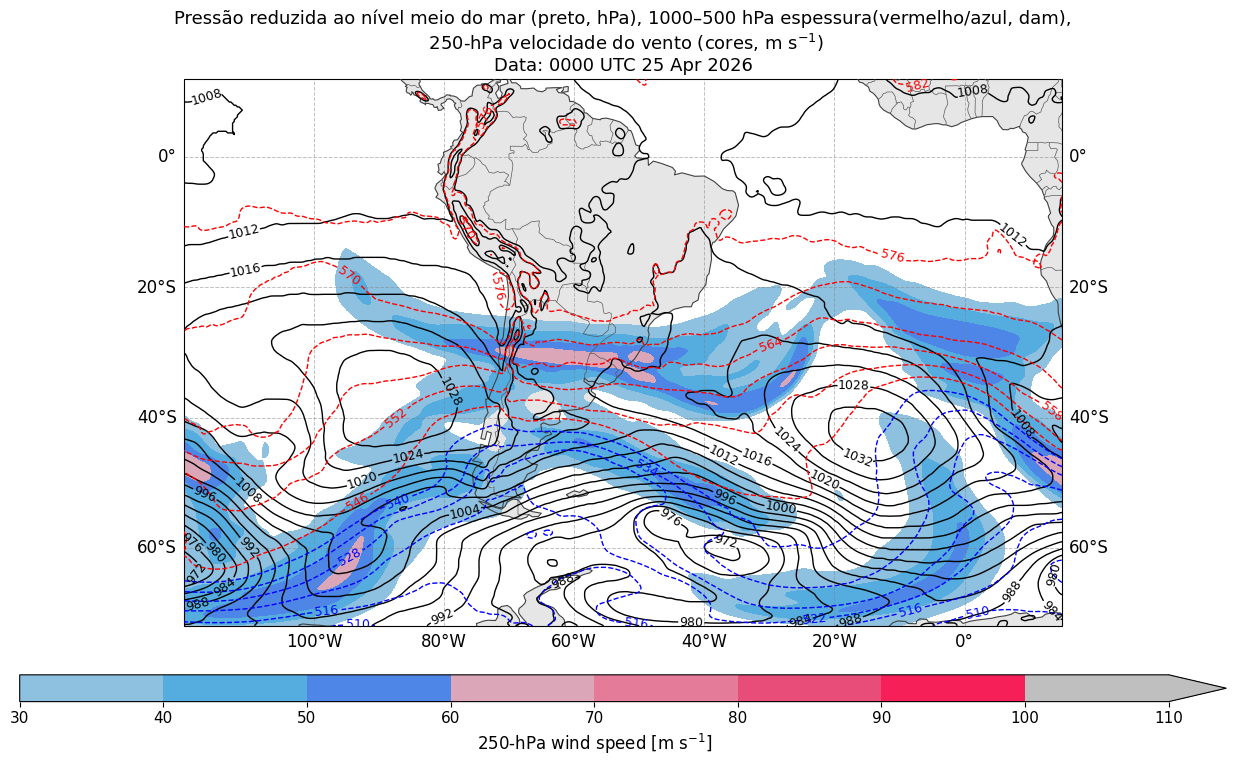

In [31]:
# @title #### <font color='#002883'> Carta sinótica de 250 hPa Jet, Thickness and MSLP <font>
#%%capture

# ==========================================================
# CONFIGURAÇÕES GERAIS
# ==========================================================

# Escolha o tempo que quer plotar
# Pode ser um índice, por exemplo: time_index = 0
time_index = 0

# Níveis de pressão necessários
level_1000 = 1000
level_500 = 500
level_250 = 250

# Gravidade para converter geopotencial em altura geopotencial
g = 9.80665

# Extrair data
valid_time = get_reanalysis_time(ds_pressure_levels, time_index=time_index)
date_line = valid_time.strftime("Data: %H%M UTC %d %b %Y")

# ==========================================================
# IDENTIFICAR NOMES DE COORDENADAS E VARIÁVEIS
# ==========================================================

# Coordenadas espaciais
lon_name_pl = find_coord(ds_pressure_levels, ["longitude", "lon"])
lat_name_pl = find_coord(ds_pressure_levels, ["latitude", "lat"])

lon_name_sl = find_coord(ds_single_levels, ["longitude", "lon"])
lat_name_sl = find_coord(ds_single_levels, ["latitude", "lat"])

# Coordenada vertical
level_name = find_coord(ds_pressure_levels, ["pressure_level", "level", "isobaricInhPa"])

# Variáveis em níveis de pressão
u_name = find_var(ds_pressure_levels, ["u", "u_component_of_wind"])
v_name = find_var(ds_pressure_levels, ["v", "v_component_of_wind"])
z_name = find_var(ds_pressure_levels, ["z", "geopotential"])

# Pressão ao nível médio do mar
msl_name = find_var(ds_single_levels, ["msl", "mean_sea_level_pressure"])

# ==========================================================
# SELEÇÃO DAS VARIÁVEIS
# ==========================================================

# MSLP
mslp = ds_single_levels[msl_name]
mslp = select_time(mslp, time_index)

# Converter Pa para hPa, se necessário
if mslp.max() > 2000:
    mslp = mslp / 100.0

mslp.attrs["units"] = "hPa"


# Geopotencial em 1000 e 500 hPa
z1000 = select_level(ds_pressure_levels[z_name], level_name, level_1000)
z500 = select_level(ds_pressure_levels[z_name], level_name, level_500)

z1000 = select_time(z1000, time_index)
z500 = select_time(z500, time_index)

# Converter geopotencial [m2 s-2] para altura geopotencial [m]
# ERA5 geralmente fornece z como geopotencial.
if z500.max() > 20000:
    z1000_hgt = z1000 / g
    z500_hgt = z500 / g
else:
    z1000_hgt = z1000
    z500_hgt = z500

# Espessura 1000–500 hPa em dam
thickness_1000_500 = (z500_hgt - z1000_hgt) / 10.0
thickness_1000_500.attrs["units"] = "dam"

# Vento em 250 hPa
u250 = select_level(ds_pressure_levels[u_name], level_name, level_250)
v250 = select_level(ds_pressure_levels[v_name], level_name, level_250)

u250 = select_time(u250, time_index)
v250 = select_time(v250, time_index)

wind250 = np.sqrt(u250**2 + v250**2)
wind250.attrs["units"] = "m s-1"

# ==========================================================
# PEGAR COORDENADAS PARA PLOT
# ==========================================================

lon_pl = ds_pressure_levels[lon_name_pl]
lat_pl = ds_pressure_levels[lat_name_pl]

lon_sl = ds_single_levels[lon_name_sl]
lat_sl = ds_single_levels[lat_name_sl]

lon_wind = wind250[lon_name_pl]
lat_wind = wind250[lat_name_pl]

lon_thick = thickness_1000_500[lon_name_pl]
lat_thick = thickness_1000_500[lat_name_pl]

lon_mslp = mslp[lon_name_sl]
lat_mslp = mslp[lat_name_sl]


# ==========================================================
# NÍVEIS DO PLOT
# ==========================================================

# Vento em 250 hPa
wind_levels = np.arange(30, 121, 10)

# MSLP em hPa
mslp_levels = np.arange(960, 1041, 4)

# Espessura 1000–500 hPa em dam
thick_levels_blue = np.arange(480, 541, 6)
thick_levels_red = np.arange(546, 601, 6)

# ==========================================================
# SUAVIZAÇÃO DAS VARIÁVEIS
# ==========================================================

sigma_mslp = 1.2
sigma_thickness = 1.2
sigma_wind = 1.0

mslp_smooth = smooth_gaussian_2d(
    mslp,
    lat_name=lat_name_sl,
    lon_name=lon_name_sl,
    sigma=sigma_mslp
)

thickness_smooth = smooth_gaussian_2d(
    thickness_1000_500,
    lat_name=lat_name_pl,
    lon_name=lon_name_pl,
    sigma=sigma_thickness
)

wind250_smooth = smooth_gaussian_2d(
    wind250,
    lat_name=lat_name_pl,
    lon_name=lon_name_pl,
    sigma=sigma_wind
)

# ==========================================================
# FIGURA
# ==========================================================

proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(13, 8))
ax = plt.axes(projection=proj)

ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)

# Fundo
ax.add_feature(cfeature.LAND, facecolor="0.90", zorder=0)
ax.add_feature(cfeature.OCEAN, facecolor="white", zorder=0)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor="0.25", zorder=3)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor="0.35", zorder=3)


# ----------------------------------------------------------
# 250-hPa wind speed sombreado
# ----------------------------------------------------------
# Intervalos da barra
wind_levels = np.arange(30, 111, 10)   # 30, 40, ..., 110

# Cores aproximadas da sua paleta
wind_colors = [
    "#8ec1df",  # 30-40
    "#55addf",  # 40-50
    "#4d86e6",  # 50-60
    "#dba6b7",  # 60-70
    "#e47b98",  # 70-80
    "#e84c78",  # 80-90
    "#f61f58",  # 90-100
    "#bfbfbf",  # 100-110
]

# Colormap discreto
cmap_wind = mcolors.ListedColormap(wind_colors)

# Normalização por intervalos
norm_wind = mcolors.BoundaryNorm(wind_levels, cmap_wind.N)

cf = ax.contourf(
    lon_wind,
    lat_wind,
    wind250_smooth,
    levels=wind_levels,
    cmap=cmap_wind,
    norm = norm_wind,
    extend="max",
    transform=proj,
    zorder=1
)


# ----------------------------------------------------------
# MSLP em preto
# ----------------------------------------------------------
cs_mslp = ax.contour(
    lon_mslp,
    lat_mslp,
    mslp_smooth,
    levels=mslp_levels,
    colors="black",
    linewidths=1.0,
    transform=proj,
    zorder=4
)

ax.clabel(cs_mslp, fmt="%d", fontsize=9, inline=True, inline_spacing=3)

# ----------------------------------------------------------
# Espessura 1000–500 hPa em azul e vermelho
# ----------------------------------------------------------
cs_thick_blue = ax.contour(
    lon_thick,
    lat_thick,
    thickness_smooth,
    levels=thick_levels_blue,
    colors="blue",
    linewidths=1.0,
    linestyles="dashed",
    transform=proj,
    zorder=5
)

cs_thick_red = ax.contour(
    lon_thick,
    lat_thick,
    thickness_smooth,
    levels=thick_levels_red,
    colors="red",
    linewidths=1.0,
    linestyles="dashed",
    transform=proj,
    zorder=5
)

ax.clabel(cs_thick_blue, fmt="%d", fontsize=9, colors="blue", inline=True)
ax.clabel(cs_thick_red, fmt="%d", fontsize=9, colors="red", inline=True)

# ----------------------------------------------------------
# Grade geográfica
# ----------------------------------------------------------
gl = ax.gridlines(
    crs=proj,
    draw_labels=True,
    linewidth=0.7,
    color="gray",
    alpha=0.5,
    linestyle="--"
)

gl.top_labels = False
gl.right_labels = True
gl.xlabel_style = {"size": 12}
gl.ylabel_style = {"size": 12}


# ----------------------------------------------------------
# Colorbar
# ----------------------------------------------------------
cbar = plt.colorbar(
    cf,
    ax=ax,
    orientation="horizontal",
    pad=0.07,
    aspect=45,
    shrink=0.95
)

cbar.set_ticks(wind_levels)
cbar.set_label("250-hPa wind speed [m s$^{-1}$]", fontsize=12)
cbar.ax.tick_params(labelsize=11)

# ----------------------------------------------------------
# Título
# ----------------------------------------------------------
title = (
    "Pressão reduzida ao nível meio do mar (preto, hPa), 1000–500 hPa espessura"
    "(vermelho/azul, dam),\n 250-hPa velocidade do vento (cores, m s$^{-1}$)\n"
    + date_line
)

ax.set_title(title, fontsize=13, loc="center")

plt.tight_layout()
plt.show()

<font size=4 color='#002883'> **10. Geração da carta sinótica de 500-hPa, Altura Geopotencial, Vorticidade, temperatura, vento e omega** <font>

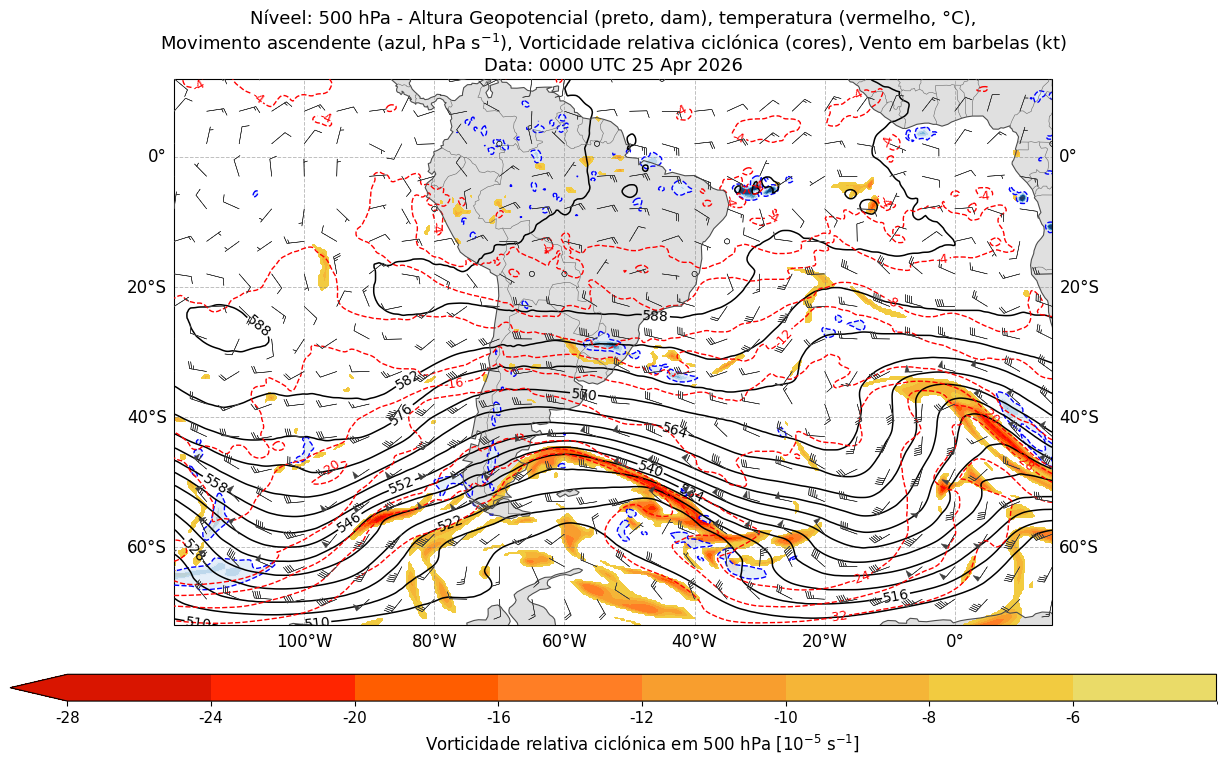

In [32]:
# @title #### <font color='#002883'> Carta sinótica de 500 hPa Altura Geopotencial, Vorticidade, vento, temperatura e omega <font>
#%%capture

# ==========================================================
# CONFIGURAÇÕES
# ==========================================================

time_index = 0
level_plot = 500

# suavização
sigma_hgt   = 1.2
sigma_temp  = 1.2
sigma_omega = 1.0
sigma_vort  = 1.0
sigma_wind  = 1.0

g = 9.80665  # gravidade

# Extrair a data
valid_time = get_reanalysis_time(ds_pressure_levels, time_index=time_index)
date_line = valid_time.strftime("Data: %H%M UTC %d %b %Y")

# ==========================================================
# IDENTIFICAR NOMES
# ==========================================================

lon_name = find_coord(ds_pressure_levels, ["longitude", "lon"])
lat_name = find_coord(ds_pressure_levels, ["latitude", "lat"])
level_name = find_coord(ds_pressure_levels, ["pressure_level", "level", "isobaricInhPa"])

u_name = find_var(ds_pressure_levels, ["u", "u_component_of_wind"])
v_name = find_var(ds_pressure_levels, ["v", "v_component_of_wind"])
z_name = find_var(ds_pressure_levels, ["z", "geopotential"])
t_name = find_var(ds_pressure_levels, ["t", "temperature"])
w_name = find_var(ds_pressure_levels, ["w", "omega", "vertical_velocity"])
vort_name = find_var(ds_pressure_levels, ["vo", "relative_vorticity"])

# ==========================================================
# SELECIONAR 500 hPa
# ==========================================================

z500 = select_time(select_level(ds_pressure_levels[z_name], level_name, level_plot), time_index)
t500 = select_time(select_level(ds_pressure_levels[t_name], level_name, level_plot), time_index)
u500 = select_time(select_level(ds_pressure_levels[u_name], level_name, level_plot), time_index)
v500 = select_time(select_level(ds_pressure_levels[v_name], level_name, level_plot), time_index)
w500 = select_time(select_level(ds_pressure_levels[w_name], level_name, level_plot), time_index)
vort500 = select_time(select_level(ds_pressure_levels[vort_name], level_name, level_plot), time_index)

# ===========================================================
# COORDENADAS
# ===========================================================
lon = z500[lon_name].values
lat = z500[lat_name].values

# ==========================================================
# CONVERSÕES
# ==========================================================

# altura geopotencial em dam
# ERA5 geralmente fornece z em m2/s2
if float(z500.max()) > 20000:
    hgt500_dam = (z500 / g) / 10.0
else:
    # se já estiver em metros
    hgt500_dam = z500 / 10.0

# temperatura em °C
if float(t500.mean()) > 100:
    temp500_c = t500 - 273.15
else:
    temp500_c = t500

# omega em hPa/s
# se w estiver em Pa/s, divide por 100
omega500_hps = w500 / 100.0

# vento em nós
u500_kt = u500 * 1.94384
v500_kt = v500 * 1.94384

# ==========================================================
# SUAVIZAÇÃO
# ==========================================================

hgt500_dam   = smooth_gaussian_2d(hgt500_dam, lat_name, lon_name, sigma=sigma_hgt)
temp500_c    = smooth_gaussian_2d(temp500_c, lat_name, lon_name, sigma=sigma_temp)
omega500_hps = smooth_gaussian_2d(omega500_hps, lat_name, lon_name, sigma=sigma_omega)
vort500      = smooth_gaussian_2d(vort500, lat_name, lon_name, sigma=sigma_vort)
u500_kt      = smooth_gaussian_2d(u500_kt, lat_name, lon_name, sigma=sigma_wind)
v500_kt      = smooth_gaussian_2d(v500_kt, lat_name, lon_name, sigma=sigma_wind)


# ==========================================================
# MÁSCARAS / CAMPOS PARA PLOT
# ==========================================================

# Ascensão = omega negativa
# limiar externo semelhante ao título: 5 x 10^-3 hPa/s
omega_ascent = xr.where(omega500_hps <= -0.005, omega500_hps, np.nan)

# Vorticidade ciclônica no HS:
# no hemisfério sul, ciclônica = negativa
vort_cyc = xr.where(vort500 <= -6e-5, vort500, np.nan)


# ==========================================================
# NÍVEIS
# ==========================================================

# altura geopotencial (dam)
hgt_levels = np.arange(510, 595, 6)

# temperatura (°C)
temp_levels = np.arange(-32, 5, 4)

# ascensão (hPa/s)
omega_levels = [-0.030, -0.025, -0.020, -0.015, -0.010, -0.005]

# vorticidade relativa ciclônica (s^-1)
# ticks vão aparecer como x10^-5 s^-1
vort_levels = np.array([-28, -24, -20, -16, -12, -10, -8, -6, -4]) * 1e-5

# colormap aproximado da figura
vort_cmap = mcolors.ListedColormap([
    "#d91500",
    "#ff2500",
    "#ff5d00",
    "#ff7e25",
    "#f89e2e",
    "#f5b537",
    "#f2cb40",
    "#eadb68",
])

vort_norm = mcolors.BoundaryNorm(vort_levels, vort_cmap.N)


# ==========================================================
# FIGURA
# ==========================================================

proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(13, 8))
ax = plt.axes(projection=proj)

ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)

# fundo
ax.add_feature(cfeature.LAND, facecolor="0.88", zorder=0)
ax.add_feature(cfeature.OCEAN, facecolor="white", zorder=0)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor="0.30", zorder=5)
ax.add_feature(cfeature.BORDERS, linewidth=0.4, edgecolor="0.40", zorder=5)


# ----------------------------------------------------------
# vorticidade ciclônica sombreada
# ----------------------------------------------------------
cf_vort = ax.contourf(
    lon, lat, vort_cyc,
    levels=vort_levels,
    cmap=vort_cmap,
    norm=vort_norm,
    extend="min",
    transform=proj,
    zorder=1
)

# ----------------------------------------------------------
# ascensão em azul
# ----------------------------------------------------------
cf_omega = ax.contourf(
    lon, lat, omega_ascent,
    levels=omega_levels,
    cmap="Blues_r",
    extend="min",
    alpha=0.90,
    transform=proj,
    zorder=2
)

# opcional: contorno do limiar externo
ax.contour(
    lon, lat, omega500_hps,
    levels=[-0.005],
    colors="blue",
    linewidths=1.0,
    transform=proj,
    zorder=3
)

# ----------------------------------------------------------
# altura geopotencial em preto
# ----------------------------------------------------------
cs_hgt = ax.contour(
    lon, lat, hgt500_dam,
    levels=hgt_levels,
    colors="black",
    linewidths=1.1,
    transform=proj,
    zorder=4
)

ax.clabel(
    cs_hgt,
    fmt="%d",
    fontsize=10,
    inline=True,
    inline_spacing=3
)

# ----------------------------------------------------------
# temperatura em vermelho
# ----------------------------------------------------------
cs_temp = ax.contour(
    lon, lat, temp500_c,
    levels=temp_levels,
    colors="red",
    linewidths=1.0,
    linestyles="dashed",
    transform=proj,
    zorder=4
)

ax.clabel(
    cs_temp,
    fmt="%d",
    fontsize=9,
    colors="red",
    inline=True,
    inline_spacing=3
)

# ----------------------------------------------------------
# barbas de vento
# ----------------------------------------------------------
skip = 20

ax.barbs(
    lon[::skip],
    lat[::skip],
    u500_kt.values[::skip, ::skip],
    v500_kt.values[::skip, ::skip],
    length=5,
    linewidth=0.4,
    color="0.25",
    transform=proj,
    zorder=6
)

# ----------------------------------------------------------
# grade
# ----------------------------------------------------------
gl = ax.gridlines(
    crs=proj,
    draw_labels=True,
    linewidth=0.7,
    color="gray",
    alpha=0.5,
    linestyle="--"
)
gl.top_labels = False
gl.right_labels = True
gl.xlabel_style = {"size": 12}
gl.ylabel_style = {"size": 12}

# ----------------------------------------------------------
# colorbar da vorticidade
# ----------------------------------------------------------
cbar = plt.colorbar(
    cf_vort,
    ax=ax,
    orientation="horizontal",
    pad=0.07,
    aspect=45,
    shrink=0.95
)

cbar.set_ticks(np.array([-28, -24, -20, -16, -12, -10, -8, -6]) * 1e-5)
cbar.set_ticklabels(["-28", "-24", "-20", "-16", "-12", "-10", "-8", "-6"])
cbar.ax.tick_params(labelsize=11)
cbar.set_label("Vorticidade relativa ciclónica em 500 hPa [$10^{-5}$ s$^{-1}$]", fontsize=12)

# ----------------------------------------------------------
# título
# ----------------------------------------------------------
title = (
    "Níveel: 500 hPa - Altura Geopotencial (preto, dam), temperatura (vermelho, °C),\n"
    "Movimento ascendente (azul, hPa s$^{-1}$), Vorticidade relativa ciclónica (cores), Vento em barbelas (kt)\n"
    + date_line
)
ax.set_title(title, fontsize=13)

# opcional: salvar
# plt.savefig("mapa_500hPa_hgt_temp_omega_vort_wind.png", dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()

<font size=4 color='#002883'> **11. Geração da carta sinótica de Precipitação, pressão reduzida ao nível médio do mar, Temperatura em 850 hPa** <font>

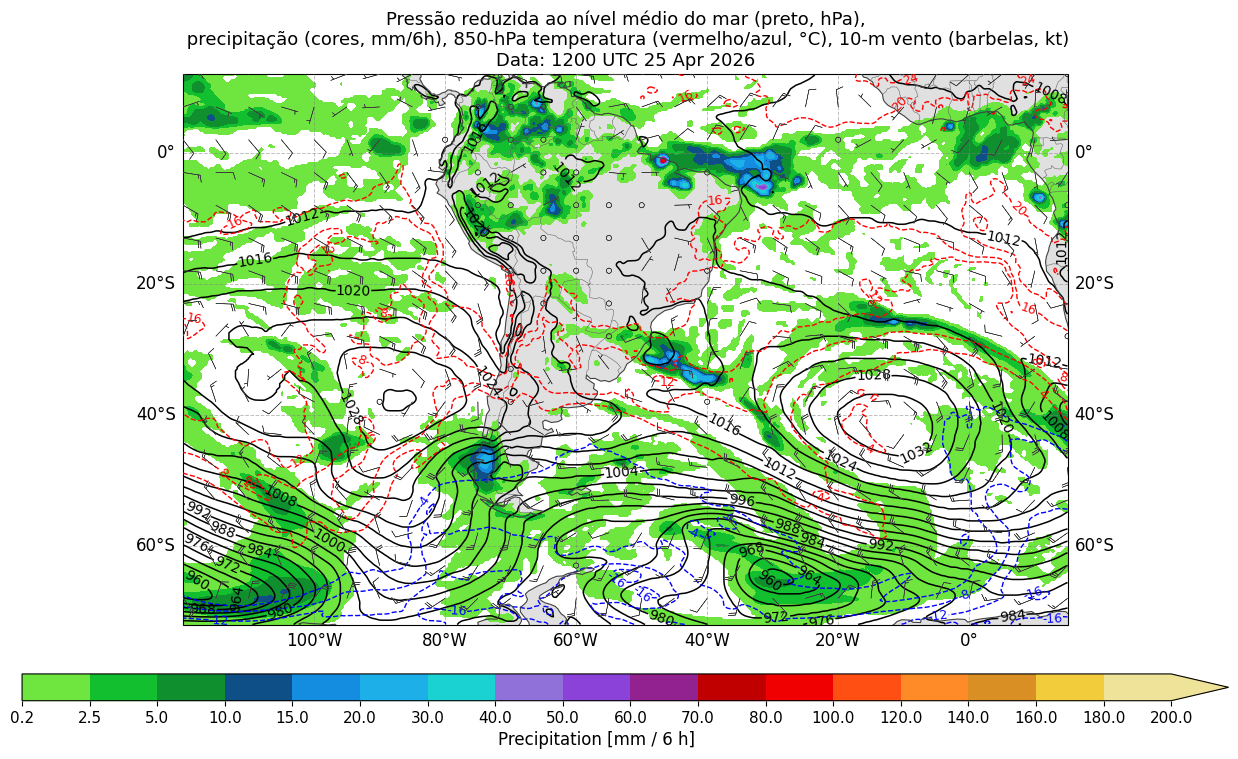

In [35]:
# @title #### <font color='#002883'> Carta sinótica de 850 hPa Temperatura, MSLP, precipitação <font>
#%%capture

# ==========================================================
# CONFIGURAÇÕES
# ==========================================================

time_index = 2
level_temp = 850  # hPa

# suavização
sigma_mslp   = 1.2
sigma_temp   = 1.0
sigma_precip = 0.8

# espaçamento das barbas
barb_skip = 20

# Extrair a data
valid_time = get_reanalysis_time(ds_pressure_levels, time_index=time_index)
date_line = valid_time.strftime("Data: %H%M UTC %d %b %Y")

# ==========================================================
# FUNÇÕES AUXILIARES
# ==========================================================

def get_time_name(ds):
    for name in ["valid_time", "time"]:
        if name in ds.coords or name in ds.dims:
            return name
    raise ValueError("Não encontrei coordenada temporal 'valid_time' ou 'time'.")

def convert_precip_to_mm(da):
    """
    Converte precipitação para mm.
    ERA5 tp geralmente vem em metros.
    """
    units = da.attrs.get("units", "").lower().strip()

    if "kg m-2" in units or "kg/m2" in units:
        out = da.copy()
        out.attrs["units"] = "mm"
        return out

    if units in ["m", "meter", "meters", "metre", "metres"]:
        out = da * 1000.0
        out.attrs["units"] = "mm"
        return out

    if "mm" in units:
        return da

    # fallback heurístico
    # se os valores forem pequenos, provavelmente estão em metros
    if float(da.max()) < 1.0:
        out = da * 1000.0
        out.attrs["units"] = "mm"
        return out

    out = da.copy()
    out.attrs["units"] = "mm"
    return out

# ==========================================================
# IDENTIFICAR COORDENADAS E VARIÁVEIS
# ==========================================================

# single levels
lon_name_sl = find_coord(ds_single_levels, ["longitude", "lon"])
lat_name_sl = find_coord(ds_single_levels, ["latitude", "lat"])
time_name_sl = get_time_name(ds_single_levels)

msl_name = find_var(ds_single_levels, ["msl", "mean_sea_level_pressure"])
tp_name  = find_var(precipitation_6h, ["tp", "total_precipitation", "precipitation"])
u10_name = find_var(ds_single_levels, ["u10", "10m_u_component_of_wind"])
v10_name = find_var(ds_single_levels, ["v10", "10m_v_component_of_wind"])

# pressure levels
lon_name_pl = find_coord(ds_pressure_levels, ["longitude", "lon"])
lat_name_pl = find_coord(ds_pressure_levels, ["latitude", "lat"])
level_name  = find_coord(ds_pressure_levels, ["pressure_level", "level", "isobaricInhPa"])

t_name = find_var(ds_pressure_levels, ["t", "temperature"])

# ==========================================================
# SELEÇÃO DAS VARIÁVEIS
# ==========================================================

# MSLP
mslp = select_time(ds_single_levels[msl_name], time_index)
prec_6h = select_time(convert_precip_to_mm(precipitation_6h[tp_name]), time_index)
# vento 10 m
u10 = select_time(ds_single_levels[u10_name], time_index)
v10 = select_time(ds_single_levels[v10_name], time_index)

# temperatura em 850 hPa
t850 = select_level(ds_pressure_levels[t_name], level_name, level_temp)
t850 = select_time(t850, time_index)

# ==========================================================
# CONVERSÕES
# ==========================================================

# MSLP: Pa -> hPa
if float(mslp.max()) > 2000:
    mslp = mslp / 100.0
mslp.attrs["units"] = "hPa"

# temperatura: K -> °C
if float(t850.mean()) > 100:
    t850 = t850 - 273.15
t850.attrs["units"] = "°C"

# vento: m/s -> kt
u10_kt = u10 * 1.94384
v10_kt = v10 * 1.94384
u10_kt.attrs["units"] = "kt"
v10_kt.attrs["units"] = "kt"

# ==========================================================
# SUAVIZAÇÃO
# ==========================================================

mslp_smooth = smooth_gaussian_2d(mslp, lat_name_sl, lon_name_sl, sigma=sigma_mslp)
t850_smooth = smooth_gaussian_2d(t850, lat_name_pl, lon_name_pl, sigma=sigma_temp)
precip_smooth = smooth_gaussian_2d(prec_6h, lat_name_sl, lon_name_sl, sigma=sigma_precip)

# mascara precipitação fraca
precip_plot = xr.where(precip_smooth >= 0.25, precip_smooth, np.nan)


# ==========================================================
# COORDENADAS
# ==========================================================

lon_sl = mslp_smooth[lon_name_sl]
lat_sl = mslp_smooth[lat_name_sl]

lon_pl = t850_smooth[lon_name_pl]
lat_pl = t850_smooth[lat_name_pl]


# ==========================================================
# NÍVEIS
# ==========================================================

# mslp
mslp_levels = np.arange(960, 1041, 4)

# temperatura 850 hPa
temp_neg_levels = np.arange(-40, 0, 4)   # azul
temp_pos_levels = np.arange(4, 41, 4)    # vermelho

# precipitação (mm/6h)
precip_levels = [
    0.25, 2.5, 5, 10, 15, 20, 30, 40, 50,
    60, 70, 80, 100, 120, 140, 160, 180, 200
]

# 17 cores para 17 intervalos
precip_colors = [
    "#6ee63f",  # 0.25-2.5
    "#12bf2f",  # 2.5-5
    "#0f8f2d",  # 5-10
    "#0f4f87",  # 10-15
    "#148de1",  # 15-20
    "#1db0e8",  # 20-30
    "#1bd2d2",  # 30-40
    "#9070d9",  # 40-50
    "#8b42d8",  # 50-60
    "#922290",  # 60-70
    "#c00000",  # 70-80
    "#f00000",  # 80-100
    "#ff4f12",  # 100-120
    "#ff8a28",  # 120-140
    "#d98f24",  # 140-160
    "#f2cc3b",  # 160-180
    "#efe39a",  # 180-200
]

precip_cmap = mcolors.ListedColormap(precip_colors)
precip_norm = mcolors.BoundaryNorm(precip_levels, precip_cmap.N)

# ==========================================================
# FIGURA
# ==========================================================

proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(13, 8))
ax = plt.axes(projection=proj)

ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)

# fundo
ax.add_feature(cfeature.LAND, facecolor="0.88", zorder=0)
ax.add_feature(cfeature.OCEAN, facecolor="white", zorder=0)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor="0.25", zorder=5)
ax.add_feature(cfeature.BORDERS, linewidth=0.4, edgecolor="0.40", zorder=5)

# ----------------------------------------------------------
# precipitação sombreada
# ----------------------------------------------------------
cf = ax.contourf(
    lon_sl,
    lat_sl,
    precip_plot,
    levels=precip_levels,
    cmap=precip_cmap,
    norm=precip_norm,
    extend="max",
    transform=proj,
    zorder=1
)

# ----------------------------------------------------------
# MSLP em preto
# ----------------------------------------------------------
cs_mslp = ax.contour(
    lon_sl,
    lat_sl,
    mslp_smooth,
    levels=mslp_levels,
    colors="black",
    linewidths=1.1,
    transform=proj,
    zorder=4
)

ax.clabel(
    cs_mslp,
    fmt="%d",
    fontsize=10,
    inline=True,
    inline_spacing=3
)

# ----------------------------------------------------------
# temperatura 850 hPa
# azul = negativa, vermelho = positiva
# ----------------------------------------------------------
cs_temp_neg = ax.contour(
    lon_pl,
    lat_pl,
    t850_smooth,
    levels=temp_neg_levels,
    colors="blue",
    linewidths=1.0,
    linestyles="dashed",
    transform=proj,
    zorder=4
)

cs_temp_pos = ax.contour(
    lon_pl,
    lat_pl,
    t850_smooth,
    levels=temp_pos_levels,
    colors="red",
    linewidths=1.0,
    linestyles="dashed",
    transform=proj,
    zorder=4
)

ax.clabel(
    cs_temp_neg,
    fmt="%d",
    fontsize=9,
    colors="blue",
    inline=True,
    inline_spacing=2
)

ax.clabel(
    cs_temp_pos,
    fmt="%d",
    fontsize=9,
    colors="red",
    inline=True,
    inline_spacing=2
)

# ----------------------------------------------------------
# vento 10 m em barbs
# ----------------------------------------------------------
ax.barbs(
    lon_sl.values[::barb_skip],
    lat_sl.values[::barb_skip],
    u10_kt.values[::barb_skip, ::barb_skip],
    v10_kt.values[::barb_skip, ::barb_skip],
    length=5,
    linewidth=0.4,
    color="0.25",
    transform=proj,
    zorder=6
)

# ----------------------------------------------------------
# grade
# ----------------------------------------------------------
gl = ax.gridlines(
    crs=proj,
    draw_labels=True,
    linewidth=0.7,
    color="gray",
    alpha=0.5,
    linestyle="--"
)

gl.top_labels = False
gl.right_labels = True
gl.xlabel_style = {"size": 12}
gl.ylabel_style = {"size": 12}

# ----------------------------------------------------------
# colorbar
# ----------------------------------------------------------
cbar = plt.colorbar(
    cf,
    ax=ax,
    orientation="horizontal",
    pad=0.07,
    aspect=45,
    shrink=0.95
)

cbar.set_ticks(precip_levels)
cbar.ax.tick_params(labelsize=11)
cbar.set_label("Precipitation [mm / 6 h]", fontsize=12)

# ----------------------------------------------------------
# título
# ----------------------------------------------------------
main_title = (
    "Pressão reduzida ao nível médio do mar (preto, hPa),\n precipitação (cores, mm/6h), "
    "850-hPa temperatura (vermelho/azul, °C), 10-m vento (barbelas, kt)\n"
    + date_line
)

ax.set_title(main_title, fontsize=13, loc="center")

# opcional: salvar
# plt.savefig("mapa_mslp_precip_t850_wind10m.png", dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()